# Iris Flower Classification
**Author:** Trisha Kollabattula | **Track:** Data Science | Oasis Infobyte SIP

**Objective:** Train machine learning models to classify iris flowers using their physical measurements.

In [1]:
!pip3 install pandas numpy matplotlib seaborn scikit-learn notebook

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [3]:
iris = load_iris()

# Convert to a DataFrame so it's easy to explore
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print("Shape:", df.shape)

Shape: (150, 5)


In [5]:
df.info()   # column names, dtypes, non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


In [6]:
print("Null values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Null values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Duplicate rows: 1


In [7]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

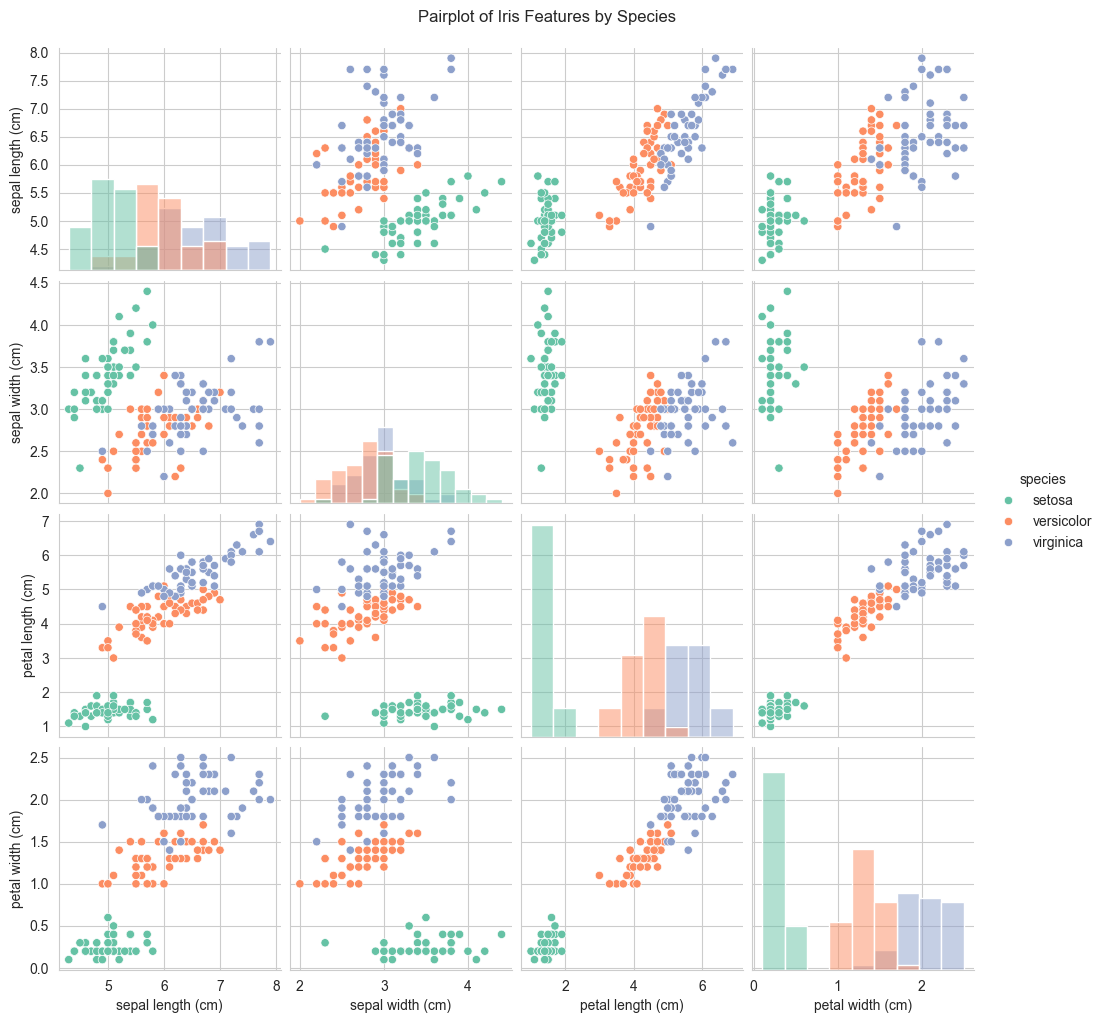

In [9]:
sns.pairplot(df, hue="species", palette="Set2", diag_kind="hist")
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

### Observations: Pairplot
- **Setosa** (one colour) forms a tight cluster that is completely separated
  from the other two species, especially in the petal length and petal width plots.
- **Versicolor and Virginica** overlap slightly, so they are harder to
  tell apart than Setosa, but they still form two distinct groups.
- Petal length and petal width show a strong positive linear relationship.
- Sepal width shows the most overlap between species, so it looks like the
  weakest feature for separating them.

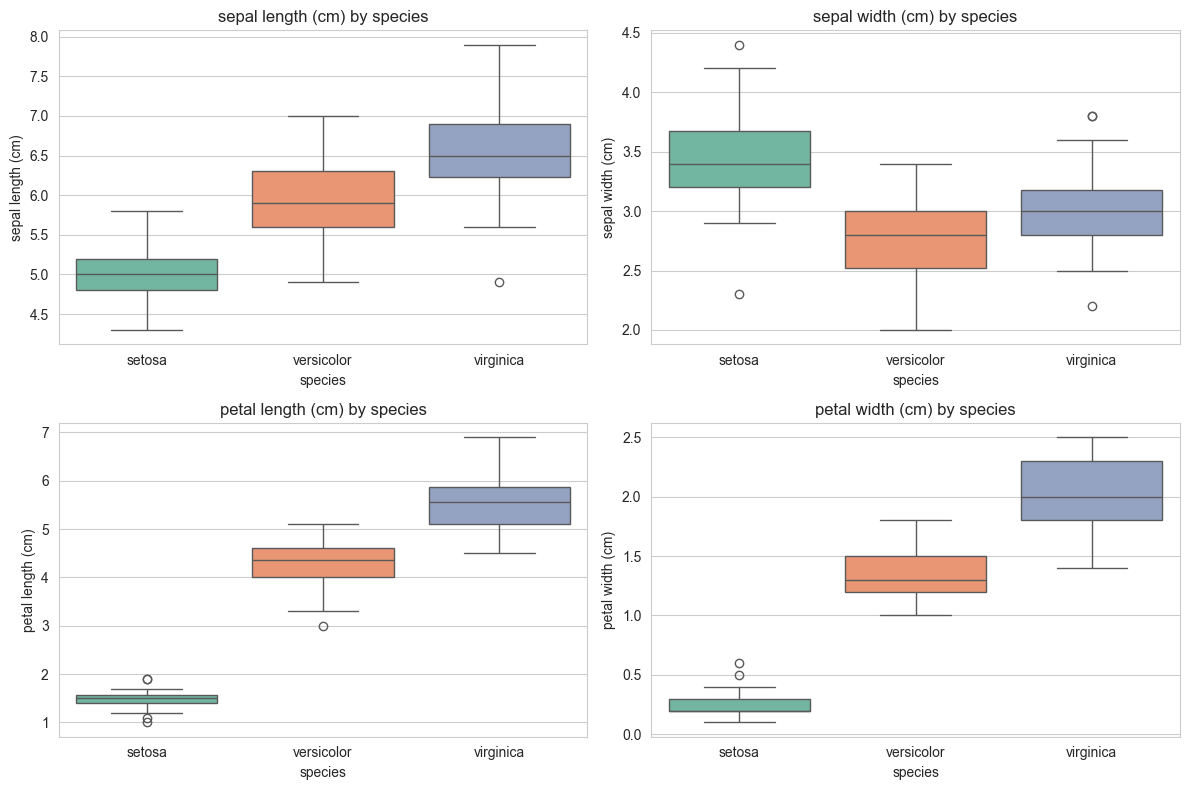

In [10]:
features = iris.feature_names

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="species", y=feature, hue="species",
                palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{feature} by species")
plt.tight_layout()
plt.show()

### Observations: Box Plots
- **Petal length and petal width:** the boxes for the three species barely
  overlap. Setosa has much smaller values, and Virginica has the largest.
  These two features separate the species best.
- **Sepal length:** there is a clear increasing trend from Setosa to
  Virginica, but the boxes overlap more.
- **Sepal width:** the boxes overlap heavily, and Setosa is actually the
  *widest* here, so this feature is not a clean separator.
- A few outlier points appear (for example in sepal width). They are
  small in number and look like natural variation, so I kept them.

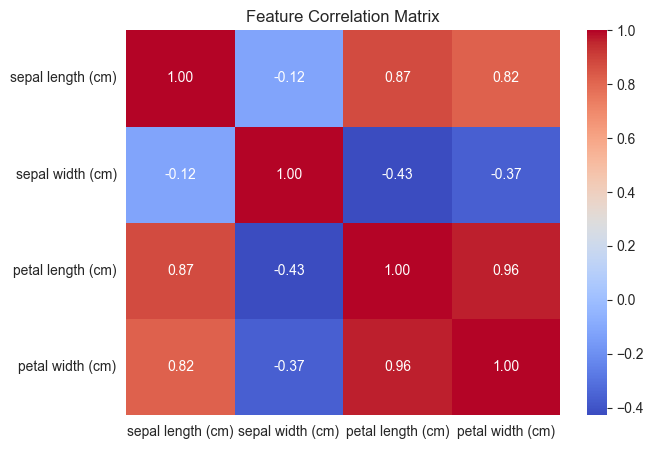

In [11]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.drop(columns="species").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [12]:
df.groupby("species", observed=True).mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


### Feature Selection Discussion
**Most discriminative features: petal length and petal width.**
- The group means show a big gap between species. Petal length goes from
  about 1.4 cm (Setosa) to about 4.2 cm (Versicolor) to about 5.5 cm (Virginica).
- The box plots and pairplot show very little overlap for these features.

**Least discriminative feature: sepal width.**
- Its means are similar across species, and the distributions overlap heavily.

**Correlation note:** petal length and petal width are very highly correlated
(about 0.96), so they carry similar information. Using both is fine for this
small dataset, but it shows that the features are partly redundant.

**Conclusion:** I expect the petal measurements to drive most of the
models' predictions.

In [13]:
X = df.drop(columns="species")
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])
print("\nClass counts in test set:")
print(y_test.value_counts())

Training samples: 120
Testing samples:  30

Class counts in test set:
species
setosa        10
versicolor    10
virginica     10
Name: count, dtype: int64


### Train/Test Split
The data is split 80% training and 20% testing. I used `stratify=y` so each
species appears in equal proportion in both sets, and `random_state=42` so
the results are reproducible.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

predictions = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results.append({"Model": name, "Test Accuracy": accuracy_score(y_test, y_pred)})

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
results_df

,Model,Test Accuracy
1,K-Nearest Neighbours,1.000000
0,Logistic Regression,0.966667
2,Decision Tree,0.933333
3,Random Forest,0.900000


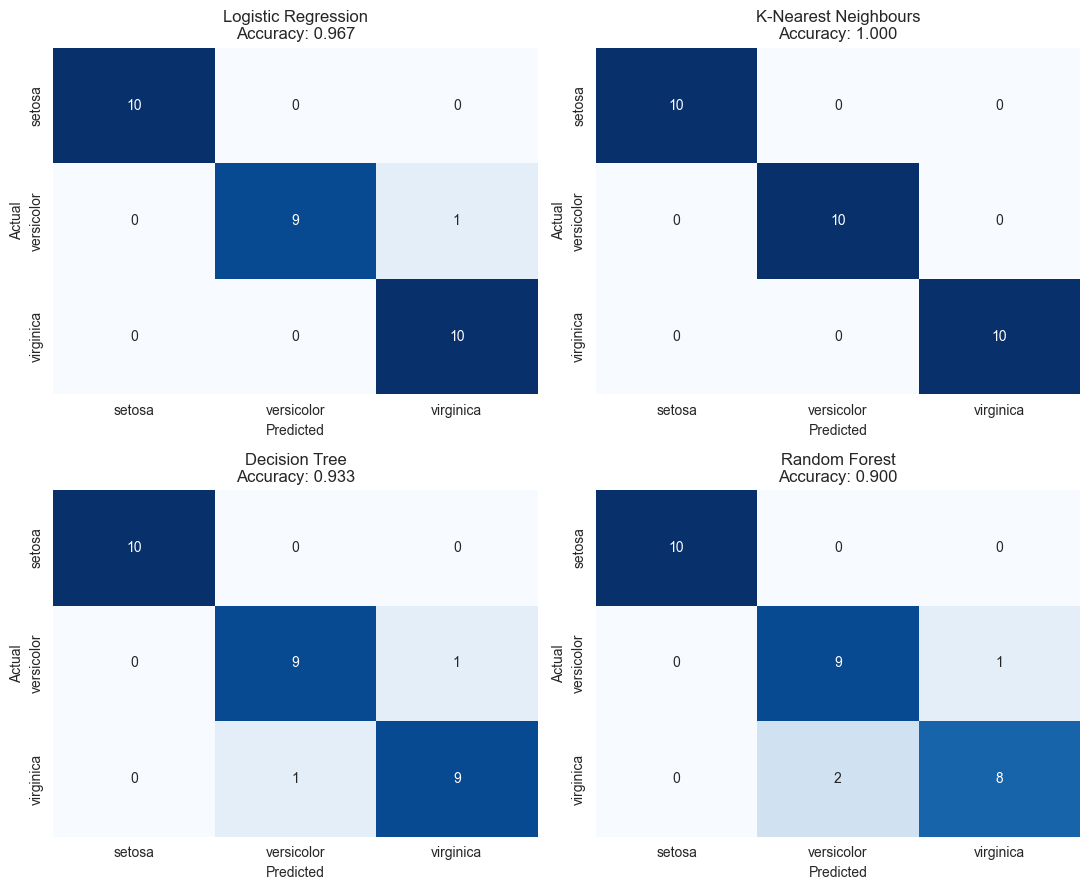

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
labels = iris.target_names

for ax, (name, y_pred) in zip(axes.flatten(), predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=labels, yticklabels=labels, cbar=False)
    ax.set_title(f"{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [16]:
for name, y_pred in predictions.items():
    print("=" * 55)
    print(name)
    print("=" * 55)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

K-Nearest Neighbours
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0

In [17]:
from sklearn.model_selection import cross_val_score

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    cv_results.append({
        "Model": name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std(),
    })

cv_df = pd.DataFrame(cv_results).sort_values("CV Mean Accuracy", ascending=False)
cv_df

,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.973333,0.024944
1,K-Nearest Neighbours,0.973333,0.024944
3,Random Forest,0.966667,0.021082
2,Decision Tree,0.953333,0.033993


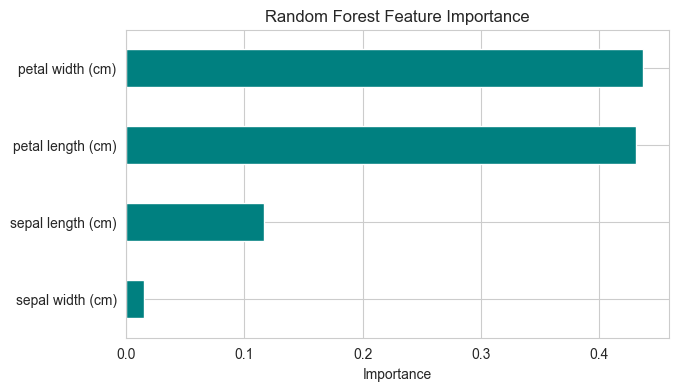

In [18]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

importances.plot(kind="barh", color="teal", figsize=(7, 4))
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

### Model Evaluation
- Test accuracies: K-Nearest Neighbours = 1.000, Logistic Regression = 0.967,
  Decision Tree = 0.933, Random Forest = 0.900.
- **Setosa is never misclassified** by any model. All errors are between
  **Versicolor and Virginica**, which matches the overlap seen in the
  pairplot and box plots.
- KNN has precision, recall and F1 of 1.00 for every class. Logistic
  Regression has one Versicolor flower predicted as Virginica
  (Versicolor recall 0.90, Virginica precision 0.91).

### Cross-Validation
The test set has only 30 samples, so one misclassified flower changes
accuracy by about 3.3%. To compare models more fairly I used 5-fold
cross-validation:
- Logistic Regression and KNN tie at **97.3%** mean accuracy.
- Random Forest scores 96.7% and Decision Tree 95.3%.
- Random Forest scored lowest on the single test split but is close to the
  top in cross-validation, so its test result was partly down to how this
  split fell.

### Best Model
I select **K-Nearest Neighbours** as the best model. It achieved 100% accuracy
on the test set (no misclassifications) and tied for the highest
cross-validation accuracy (97.3%). Logistic Regression performs almost
identically and is a simpler alternative. Because the dataset is small and
all four models are within a few percentage points, I would not claim any
model is far superior. The Versicolor/Virginica boundary is the only
real difficulty.

### Feature Importance
The Random Forest ranks **petal width and petal length** far above the
sepal features (sepal width is almost unused), confirming the conclusion
from the EDA.